# 03_collateral_projection · Pool projection & scenarios: the handoff to the waterfall

**Purpose.** Project the whole STACR reference pool month by month to the Feb 2031 call (53 months) under several scenarios, and produce the table that Smarajit's `src/waterfall.py` consumes. His waterfall only needs this table, not how CPR or defaults were modeled.

**Process (`src/collateral_projection.py`).**
1. **Scheduled principal**: level-pay amortization. Payment = B·r / (1 − (1+r)⁻ⁿ), and principal = payment − B·r. Checked by hand: $300k, 6.75%, 342 months gives month-1 principal of $290.46.
2. **`project_collateral`, one path.** The pool is loaded with `load_pool()`: the post-August Bloomberg tape rolled forward one month to the post-September balance of $19.254bn (Bloomberg CLP), so the start matches the tranche balances in the waterfall. A September tape in `data/raw/` (named `..._2026-09.xlsx`) replaces the approximation automatically. Each month, in this order so no dollar leaves twice:
   1. *Defaults*: MDR × performing balance enter a 19-month **liquidation pipeline** (fitted median). They stay in the reference pool, counted in `distressed_balance`, which feeds the STACR Delinquency Test. 57% of new default spells never liquidate (cure, modification or payoff in the data); they stay performing at a slightly lower rate.
   2. *Scheduled principal* on the remaining performing balance.
   3. *Prepayments*: SMM × (balance after scheduled principal).
   4. *Credit events*: loans whose 19-month lag ends leave the pool, and **loss** = balance × severity at that month's HPI. Loans already 60+ days delinquent or in bankruptcy/foreclosure on the tape start in the pipeline and liquidate in month 9.

   Balance identity: ending = beginning − scheduled − prepayments − credit events (checked every month).
3. **`run_scenarios`** on `get_scenarios()`: Coco's paths from `data/scenarios/scenarios.csv` when that file exists, otherwise **interim** good / base / moderate / severe paths built around today's PMMS of 7.28% (see `data/scenarios/README.md` for the file format).
4. **Figure 3** and a summary of cumulative losses against the tranche attachment points.
5. **Save** each scenario's table to `outputs/pool_cf_<scenario>.parquet` for the waterfall.

Output columns: `month, beginning_balance, scheduled_principal, prepayments, defaults (credit events), losses, recoveries, ending_balance, modification_losses, distressed_balance`, all in $.

In [1]:
import sys, warnings
from pathlib import Path

# Find the repo root (the folder that contains src/) so imports work from anywhere
ROOT = Path.cwd()
while not (ROOT / "src").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
warnings.filterwarnings("ignore", category=FutureWarning)  # pandas 2.2 + Python 3.14 noise

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.float_format", "{:,.4f}".format)
print("repo root:", ROOT)

repo root: /Users/reza/Desktop/mfe-term_3/asset backed scurity market /stacr-crt-pricing


**Q&A · Setup**

**Q: Why does the first cell search upward for a folder containing `src/`?**
A: The model code lives in `src/` at the repo root. Jupyter may start in the repo root or in `notebooks/`, so the cell walks up the folder tree until it finds `src/` and adds that folder to `sys.path`. Then `from src import ...` works wherever the notebook is opened.

**Q: Why are FutureWarnings turned off? Doesn't that hide problems?**
A: pandas 2.2 running on Python 3.14 prints spurious "chained assignment" warnings from `clean.py`, which drown out the real output. Only *warnings* are hidden. Real errors still stop the cell, so nothing that would make a result wrong is suppressed.

In [2]:
def try_run(fn, *args, **kwargs):
    """Call a model function; if it's still a stub, say so instead of crashing."""
    try:
        return fn(*args, **kwargs)
    except NotImplementedError:
        print(f"-> {fn.__module__}.{fn.__name__} is not implemented yet")
        return None

**Q&A · `try_run`**

**Q: What does `try_run` do, and is it still needed?**
A: It calls a model function and, if the function raises `NotImplementedError`, prints "not implemented yet" instead of crashing. It dates from the scaffold stage, when the functions were empty stubs. Every function is implemented now, so `try_run` just returns the result. It's harmless and keeps the notebook runnable if a function is ever replaced by a stub again.

In [3]:
from src import collateral_projection as cp
pool = cp.load_pool()   # post-September 2026 pool: the August tape rolled forward one month
print(f"tape as of {pool.attrs['tape_as_of']}, rolled forward {pool.attrs['rolled_forward_months']} month(s)")
print(f"{len(pool):,} loans, ${pool['Current Balance'].sum()/1e9:.2f}bn")
print('output columns:', cp.COLUMNS)

tape as of 2026-08, rolled forward 1 month(s)
56,871 loans, $19.25bn
output columns: ['month', 'beginning_balance', 'scheduled_principal', 'prepayments', 'defaults', 'losses', 'recoveries', 'ending_balance', 'modification_losses', 'distressed_balance']


**Q&A · Loading the pool**

**Q: Why use the full pool here rather than a sample?**
A: This notebook produces the cash flows that Smarajit's waterfall allocates to A-1, M-1 and M-2. They must add up to the real reference pool (the post-September $19.25bn, from the August tape rolled forward one month), so all 56,871 loans are projected. The code is vectorized, so a 53-month projection still takes about a second.

**Q: What are the output columns for?**
A: `scheduled_principal` + `prepayments` + `defaults` (balance leaving through credit events) are the principal flows; `losses` drive write-downs; `modification_losses` cut tranche interest; `distressed_balance` feeds the Delinquency Test; `beginning_balance`/`ending_balance` let the waterfall check the Senior Percentage and the clean-up call.

## Step 1 · Scheduled principal

> Check by hand: $300k, 6.75%, 342 months left. What's month-1 principal?

In [4]:
sp = try_run(cp.scheduled_principal, np.array([300_000.0]), np.array([6.75]), np.array([342]))
print(sp)

[290.4585561]


**Result · Scheduled principal.** **$290.46**, matching the hand check (payment $1,977.96 − interest $1,687.50).

**Q&A · Scheduled principal**

**Q: Where does the payment formula come from?**
A: A fixed-rate mortgage is an annuity: the balance B equals the present value of n equal payments at the monthly rate r = coupon/1200. Solving B = P·[1 − (1+r)⁻ⁿ]/r for the payment gives P = B·r / (1 − (1+r)⁻ⁿ). Each month interest is B·r, and the rest of the payment is principal.

**Q: Why is month-1 principal only $290 of a $1,978 payment?**
A: Early in a 30-year loan the balance is large, so interest (B·r = $1,687.50) takes most of the payment. Principal only overtakes interest around month 220. That's why scheduled principal is just about 0.1% of the pool a month, and prepayment drives the pool's paydown.

## Step 2 · One path → monthly table

> Within a month, which balance does SMM apply to, and which does MDR? Does your table conserve balance?

In [5]:
N_MONTHS = 53
flat_rate = np.full(N_MONTHS, cp.PMMS_TODAY)   # today's PMMS, 7.28%
flat_hpi = np.ones(N_MONTHS + 1)

cf = try_run(cp.project_collateral, pool, flat_hpi, flat_rate, N_MONTHS)
if cf is not None:
    out = cf["scheduled_principal"] + cf["prepayments"] + cf["defaults"]
    print("max balance error ($):", (cf["beginning_balance"] - out - cf["ending_balance"]).abs().max())
    display(cf.head(12))

max balance error ($): 3.814697265625e-06


,month,beginning_balance,scheduled_principal,prepayments,defaults,losses,recoveries,ending_balance,modification_losses,distressed_balance
0,1,"19,254,308,000.0000","18,708,701.2251","136,969,305.3218",0.0000,0.0000,0.0000,"19,098,629,993.4532",0.0000,"54,763,755.4532"
1,2,"19,098,629,993.4532","18,680,686.3499","135,502,285.5057",0.0000,0.0000,0.0000,"18,944,447,021.5976","1,997.8077","62,123,540.5782"
2,3,"18,944,447,021.5976","18,652,964.5231","134,059,377.3842",0.0000,0.0000,0.0000,"18,791,734,679.6904","3,955.1507","69,399,541.2529"
3,4,"18,791,734,679.6904","18,625,528.8576","132,639,864.9264",0.0000,0.0000,0.0000,"18,640,469,285.9063","5,872.8115","76,593,007.6786"
4,5,"18,640,469,285.9063","18,598,372.7105","131,243,063.8974",0.0000,0.0000,0.0000,"18,490,627,849.2984","7,751.5516","83,705,163.0430"
5,6,"18,490,627,849.2984","18,571,489.6707","129,868,320.0396",0.0000,0.0000,0.0000,"18,342,188,039.5881","9,592.1123","90,737,204.3582"
6,7,"18,342,188,039.5881","18,544,873.5490","128,515,007.3820",0.0000,0.0000,0.0000,"18,195,128,158.6570","11,395.2155","97,690,303.2626"
7,8,"18,195,128,158.6570","18,518,518.3675","127,182,526.6625",0.0000,0.0000,0.0000,"18,049,427,113.6271","13,161.5645","104,565,606.7886"
8,9,"18,049,427,113.6271","18,492,418.3504","125,870,303.8580","47,318,907.7843","22,467,099.4344",0.0000,"17,857,745,483.6345","14,891.8445","64,045,330.3123"
9,10,"17,857,745,483.6345","18,466,567.9147","124,577,788.8117",0.0000,0.0000,0.0000,"17,714,701,126.9081","16,586.7235","70,768,389.3956"


**Result · One path (flat HPI, today's 7.28% PMMS, fitted parameters).** The balance identity holds every month (max error < $0.00001), starting at the post-September **$19.25bn**.
- **Prepayments still dominate, but slowly**: about **$137mm** in month 1 vs **$19mm** of scheduled principal. With the pool about 0.5 pp out of the money, CPR is only about 8%.
- **Credit events**: zero in months 1–8, then **$47.3mm in month 9**. Those are the loans already 60+ days late or coded B/F on the tape, liquidating halfway through the 19-month lag, with a **$22.5mm loss** (48% severity). New defaults only start liquidating in month 20.
- **`distressed_balance`** starts at about **$55mm**, rises to about $91mm by month 6, drops to about $64mm after the month-9 liquidations, peaks near **$105mm**, and is still about $58mm in 2031, because the slow-paying pool keeps more loans exposed. This column feeds the waterfall's Delinquency Test.
- **`modification_losses`** grow to about **$55k a month** by 2031, still small next to liquidation losses.

**Q&A · One path, the monthly table**

**Q: Within a month, which balance does SMM apply to, and which does MDR? (the question in Step 2)**
A: The order is defaults → scheduled principal → prepayments. MDR applies to the **performing balance at the start of the month**. Scheduled principal is computed on what's left after defaults. SMM then applies to the balance **after** both. Each dollar can leave only one way, which is why the balance identity (ending = beginning − scheduled − prepayments − credit events) holds to within a fraction of a cent.

**Q: Why is there a spike of credit events in month 9?**
A: Loans that were already 60+ days late, or in bankruptcy/foreclosure (codes B/F), on the tape start in the liquidation pipeline. The model assumes they're halfway through the 19-month lag, so they liquidate in month 9: $47.8mm with a $22.7mm loss. New defaults only reach liquidation from month 20.

**Q: Why does `distressed_balance` matter to the waterfall?**
A: STACR's Delinquency Test compares the 6-month average distressed balance (60+ days late, in foreclosure, REO or recently modified) with 50% of the subordinate cushion. If it fails, all principal goes to the senior classes and the mezzanine notes stop amortizing, which lengthens their life and loss exposure.

## Step 3 · Scenarios

Placeholder paths; swap in Coco's from `src/scenarios.py`.

In [6]:
# Coco's paths from data/scenarios/scenarios.csv if that file exists, otherwise the
# interim paths built around today's PMMS (cp.placeholder_scenarios)
scenarios = cp.get_scenarios(N_MONTHS)
print("source:", "Coco's scenarios.csv" if cp.SCENARIO_CSV.exists() else "interim placeholder paths")
print(pd.DataFrame({k: {"mortgage rate (%)": v["rate"][0], "HPI at month 53": v["hpi"][-1]} for k, v in scenarios.items()}).T.round(3))
results = try_run(cp.run_scenarios, pool, scenarios, N_MONTHS)

source: Coco's scenarios.csv
          mortgage rate (%)  HPI at month 53
base                 7.2280           1.2230
good                 7.2250           1.3210
moderate             7.1530           0.8630
severe               7.3040           0.7890


**Result · Scenarios (Coco's `scenarios.csv`).** `get_scenarios` found Coco's file in `data/scenarios/`, built by `python -m src.scenarios --download` from FRED data as of 2026-10-03. All four paths start at today's PMMS of **7.28%**:

| scenario | how it's built | mortgage rate, month 12 → 53 | HPI by Feb 2031 |
|---|---|---|---|
| good | 75–85th percentile of 20,000 simulated paths | 6.70% → 5.67% | **+32%** |
| base | 45–55th percentile (median) | 6.74% → 5.79% | **+22%** |
| moderate | replay of Dec 2005 – May 2010 (10th-percentile window) | 7.14% → 5.90% | **−14%** |
| severe | replay of Mar 2007 – Aug 2011 (worst window) | 7.09% → 5.39% | **−21%** |

In every path rates drift down toward their 2000–2026 average, so the pool gradually moves into the money. Month 1 is a 22-day stub period (Oct 3 → Oct 25 payment date); the collateral model treats it as a full month.

**Q&A · Scenarios**

**Q: How did Coco build the paths?**
A: She fits a simple time-series model (AR(1) for each of short rate, 2-year and 10-year Treasury, mortgage spread and HPI growth) on monthly FRED data from 2000, simulates 20,000 joint paths by resampling historical shocks in 6-month blocks, and averages the paths in an HPI-percentile band for good and base. Moderate and severe replay actual historical 53-month windows (the 2006–2011 housing bust), re-anchored to today's rates.

**Q: Why do rates fall in every scenario, even base?**
A: The model pulls rates back toward their long-run average since 2000 (around 5.5–6% for mortgages). Starting from 7.28%, that means a gradual decline, which matters a lot for prepayment because the pool's coupon is 6.76%.

**Q: What about the 22-day first month?**
A: Coco's month 1 runs from today (Oct 3) to the first payment date (Oct 25). The collateral model applies a full month's prepayment and default rates, which overstates month-1 flows by about 8 days' worth, roughly 2% of a year's activity. It's small, but worth fixing if Smarajit's waterfall uses exact accrual days.

### Figure 3 · Projected reference-pool balance

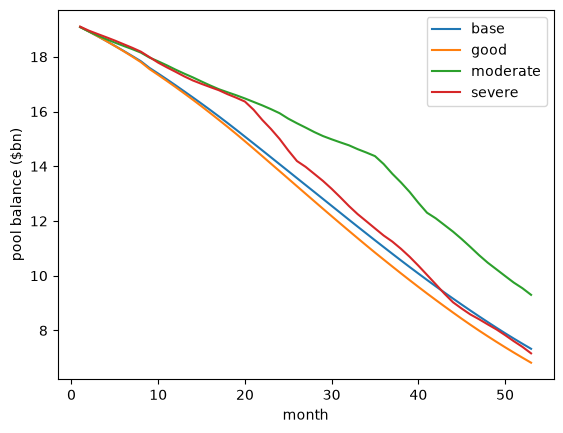

In [7]:
if results:
    for name, df in results.items():
        plt.plot(df["month"], df["ending_balance"] / 1e9, label=name)
    plt.xlabel("month"); plt.ylabel("pool balance ($bn)"); plt.legend()

**Result · Figure 3 (pool balance, Coco's scenarios).**

| | month 12 | month 24 | month 36 | month 53 | half paid down by |
|---|---|---|---|---|---|
| good | $16.9bn | $13.8bn | $10.6bn | **$6.82bn** | month 40 |
| base | $17.0bn | $14.1bn | $11.0bn | **$7.33bn** | month 42 |
| moderate | $17.5bn | $15.9bn | $14.1bn | **$9.30bn** | month 52 |
| severe | $17.5bn | $15.0bn | $11.5bn | **$7.16bn** | month 43 |

Prepayment starts slow (year-1 CPR **8–11%**, the pool is out of the money) and speeds up as rates fall: by year 4 CPR is about **24–27%** in every scenario. Moderate pays down slowest because its rates stay near 7.1% for the first two years.

**Q&A · Figure 3, pool balance**

**Q: Why does the curve bend down later in the projection?**
A: Rates in Coco's paths fall below the pool's 6.76% average coupon in years 3–4, so refinancing switches on and CPR rises from about 10% to about 25%.

**Q: Why does severe end with a smaller pool than moderate?**
A: Severe's rates fall further (to 5.4% vs 5.9%), so more borrowers who still have equity refinance late in the horizon, and more loans also leave through liquidation. The model still lets underwater borrowers refinance, which flatters this.

**Q: How does the paydown affect the notes?**
A: Compared with the interim flat-7.28% paths, the notes extend in year 1–2 but pay down faster afterwards. The pool is about $7bn at the 2031 call in good, base and severe, and $9.4bn in moderate. For the first 36 months A-1 gets its fixed paydown schedule from the senior share; the mezzanine notes amortize sequentially from the subordinate share while the triggers pass.

In [8]:
if results:
    display(pd.DataFrame({name: {
        "cum. losses ($mm)": df["losses"].sum() / 1e6,
        "cum. loss / cut-off (%)": df["losses"].sum() / cp.CUTOFF_BALANCE * 100,
        "end balance ($bn)": df["ending_balance"].iloc[-1] / 1e9,
    } for name, df in results.items()}))

,base,good,moderate,severe
cum. losses ($mm),47.2683,43.4332,65.2052,80.7587
cum. loss / cut-off (%),0.2075,0.1907,0.2862,0.3545
end balance ($bn),7.3291,6.8210,9.3010,7.1630


**Result · Losses vs the tranche stack (Coco's scenarios).** Cumulative losses (good / base / moderate / severe) are **$43.4mm / $47.3mm / $65.2mm / $80.8mm**, or **0.191% / 0.207% / 0.286% / 0.354%** of the $22.78bn cut-off balance.
- The first-loss piece **B-3H covers 0–0.25%**: good and base stay inside it, while **moderate and severe go into B-2H**, by about $8mm and $24mm.
- The offered **M-2B (attaching at 1.90%), M-1 and A-1 still take no write-downs**; the severe loss is about a fifth of M-2B's attachment point.
- About $21–24mm of each scenario's loss comes from loans already delinquent on the tape, so it's locked in whatever the scenario.

> Compare cumulative loss / cut-off with the tranche bands in `docs/cashflows.md` (B-3H 0–0.25%, B-2H 0.25–1.45%, …, M-2B attaches at 1.90%). Which scenario reaches the offered notes?

**Q&A · Losses vs the tranche stack**

**Q: How do I read "loss / cut-off" against the tranches?**
A: Attachment and detachment points are percentages of the **cut-off** balance ($22.78bn). A tranche is written down only once cumulative losses pass its attachment point. B-3H covers 0–0.25%, B-2H 0.25–1.45%, B-1H 1.45–1.90%, and M-2B starts at 1.90%.

**Q: Why are the offered notes still safe in the severe case?**
A: Severe losses are 0.354% of cut-off. They use all of B-3H and about 0.10% (≈$24mm) of B-2H. The offered notes sit behind 1.90% of subordination, about 5.4× the severe loss.

**Q: How do these compare with the interim flat-7.28% paths?**
A: Very close in the stress cases (moderate 0.286% vs 0.289%, severe 0.354% vs 0.342%) and a bit lower in base (0.207% vs 0.234%), because Coco's base has stronger house prices (+22% vs +13%) and falling rates that let loans pay off before they can default.

## Step 4 · Save the handoff for Smarajit

In [9]:
if results:
    out_dir = ROOT / "outputs"; out_dir.mkdir(exist_ok=True)
    for name, df in results.items():
        df.to_parquet(out_dir / f"pool_cf_{name}.parquet", index=False)
    print("saved to", out_dir)

saved to /Users/reza/Desktop/mfe-term_3/asset backed scurity market /stacr-crt-pricing/outputs


**Result · Saved.** Four files are in `outputs/`: `pool_cf_good.parquet`, `pool_cf_base.parquet`, `pool_cf_moderate.parquet` and `pool_cf_severe.parquet`, each with 53 rows and the 10 agreed columns, now built from Coco's scenarios. `python -m src.export_results` writes the same tables as CSV in `outputs/tables/`. These are what Smarajit's waterfall reads; for discounting and SOFR coupons he should use Coco's `data/scenarios/pricing_rates.csv`.

**Q&A · Saving the handoff**

**Q: Why parquet files, and why are they gitignored?**
A: Parquet keeps exact numeric types and loads instantly in pandas. The tables are built from licensed Bloomberg data, so they stay local (`outputs/` is gitignored) and teammates regenerate them by running this notebook.

**Q: How will Smarajit use them?**
A: Scheduled principal + prepayments make up the deal's Stated Principal, which the waterfall splits between the senior and subordinate shares. `losses` become tranche write-downs from the bottom up. `modification_losses` reduce junior interest. `distressed_balance` and cumulative losses drive the Delinquency and Cumulative Net Loss tests.

## Results and takeaways (fitted parameters, Coco's scenarios)

- **The table is consistent**: the balance identity holds every month, and month 1 starts at the post-September **$19.25bn** (August tape rolled forward one month).
- **Prepayment starts slow and speeds up**: year-1 CPR is about **8–11%** (the pool is out of the money at 7.28%), rising to about **24–27%** by year 4 as Coco's rates drift down toward 5.4–5.9%.
- **Pool runoff to the Feb 2031 call**: **$6.82bn / $7.33bn / $9.30bn / $7.16bn** (good / base / moderate / severe).
- **Credit events**: $47.3mm of loans already seriously delinquent liquidate in month 9 (a $21–24mm loss). New defaults start liquidating after the fitted 19-month lag.
- **Losses**: **0.191% / 0.207% / 0.286% / 0.354%** of cut-off. Good and base stay inside **B-3H (0–0.25%)**; moderate and severe reach **B-2H**. **A-1, M-1 and M-2 take no write-downs**: M-2B needs cumulative losses above 1.90%, about 5.4× the severe case.

**What this means and what's next.** The offered notes remain well protected against credit loss. Their main risk is timing: slow paydown in the first two years (extension), then faster paydown as rates fall. Next: (1) Smarajit runs the waterfall on these tables, discounting with Coco's `pricing_rates.csv`; (2) handle the 22-day first period exactly; (3) add a negative-equity block on refinancing, which matters for the severe path where rates fall while prices drop.